- In this the messages stored in memory save get delete

In [1]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain.messages import RemoveMessage

In [2]:
from langchain_core.messages import BaseMessage, HumanMessage


In [12]:
import os
load_dotenv()
api_key = os.environ['GROQ_API_KEY1']
model = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
    api_key=api_key,
    verbose=True,
    # other params...
)

In [13]:
def chat(state: MessagesState):
    response = model.invoke(state["messages"])
    return {"messages": [response]}

def delete_old_messages(state: MessagesState):
    msgs = state["messages"]

    # if more than 10 messages, delete the earliest 6
    if len(msgs) > 10:
        to_remove = msgs[:6]
        return {"messages": [RemoveMessage(id=m.id) for m in to_remove]}

    return {}

In [14]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat)
builder.add_node("cleanup", delete_old_messages)

In [15]:
builder.add_edge(START, "chat")
builder.add_edge("chat", "cleanup")   # run deletion after each response
builder.add_edge("cleanup", "__end__")

In [16]:
graph = builder.compile(checkpointer=InMemorySaver())

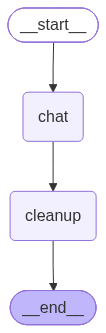

In [9]:
graph

In [10]:
config = {"configurable": {"thread_id": "t1"}}

- Below there is total 14 conversation 7 humanmessages and 7 aimessages

In [17]:
graph.invoke({"messages": [{"role": "user", "content": "Hi, I'm Ram"}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Tell me about LangGraph in short form."}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "Now explain checkpointers in short form."}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Langchain n short form."}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Quantum Mechanics n short form."}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is Gen AI n short form."}]}, config)
graph.invoke({"messages": [{"role": "user", "content": "What is my name"}]}, config)

{'messages': [HumanMessage(content='What is Langchain n short form.', additional_kwargs={}, response_metadata={}, id='810226de-63d9-4de5-930d-7b92593a5e11'),
  AIMessage(content='**LangChain – Short Form**\n\n- **What it is**: A Python framework that makes it easy to build applications powered by large language models (LLMs).  \n- **Core idea**: Treat an LLM as a *tool* that can be combined with other tools (APIs, databases, memory, etc.) to create complex, stateful workflows.  \n- **Key building blocks**  \n  1. **Chains** – linear sequences of prompts or function calls.  \n  2. **Agents** – LLMs that decide which tool to use next.  \n  3. **Memory** – persistent context (e.g., conversation history).  \n  4. **Tools** – wrappers around external services (SQL, web search, custom APIs).  \n  5. **Prompt templates** – reusable prompt patterns.  \n- **Why use it**  \n  - Rapid prototyping of LLM‑driven apps.  \n  - Plug‑and‑play with many LLM providers (OpenAI, Anthropic, Azure, etc.).  \

In [19]:
snap = graph.get_state(config)
print("Stored messages after cleanup:", len(snap.values["messages"]))

Stored messages after cleanup: 8
